# Word-Level Dialect Analysis
Cross-compares every source word against every word in the DAT and DIT transcripts using:

- **Levenshtein similarity**
- **Position score** (normalised gap between source and target word index)

Scoring methods:
- **Combined Weighted Score**: $\alpha \cdot \text{lev\_sim} + (1-\alpha) \cdot \text{pos\_sim}$, evaluated for $\alpha \in \{0.25,\ 0.5,\ 0.75\}$
- **Combined Harmonic Score**: $\frac{2 \cdot \text{lev\_sim} \cdot \text{pos\_sim}}{\text{lev\_sim} + \text{pos\_sim}}$

In [1]:
import sys
import importlib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# Make scripts/ importable when running from inside scripts/
sys.path.insert(0, str(Path("__file__").resolve().parent))

import util.utils as utils
importlib.reload(utils)

from util.utils import (
    clean,
    build_word_comparison_df,
)

In [2]:
PROJECT_ROOT = Path("__file__").resolve().parent.parent
ANALYSIS_DIR = PROJECT_ROOT / "samples"
DAT_TSV = ANALYSIS_DIR / "dialect-aware-transcript.tsv"
DIT_TSV = ANALYSIS_DIR / "dialect-ignorant-transcript.tsv"

## Load & merge data

In [3]:
df_dit = pd.read_csv(DIT_TSV, sep='\t', encoding='utf-8-sig')
df_dat = pd.read_csv(DAT_TSV, sep='\t', encoding='utf-8-sig')
df = pd.merge(df_dit, df_dat[['path', 'DAT']], on='path', how='inner')

print(f"Clips: {len(df)}")
df.head(3)

Clips: 100


,path,duration,sentence,sentence_source,client_id,dialect_region,canton,zipcode,age,gender,DIT,DAT
0,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,4.778662,Insgesamt habe ich einige Hunderttausend Frank...,news,300bb931-79ae-40ec-b989-3efd5e83f4c2,Zürich,ZH,8408.0,fourties,male,Insgesamt habe ich einige hundert Dusik vor un...,Insgesamt habe ich einige 100.000 Franken verl...
1,clips\6e084270-8d26-43d9-ba69-5e8ee793ab8c\dca...,5.294150,Welche Rolle hatte Rosenberg während des Holoc...,news,6e084270-8d26-43d9-ba69-5e8ee793ab8c,Zürich,ZG,6340.0,twenties,female,"Weli Rolle, höchter Uz stoodhergewerden von Ho...",Wer ironne hättet viele bands auf den einzugem...
2,clips\6858a37b-edd0-4fdf-871c-96d3b1bd3e21\82f...,5.802676,Das ist angesichts aller schlechten Optionen d...,news,6858a37b-edd0-4fdf-871c-96d3b1bd3e21,Zürich,ZH,8704.0,fourties,male,Das ist angesichts vor allen Schlachten Option...,Das ist angesichts von allen schlechten Option...


In [4]:
df[["sentence", "DIT", "DAT"]].isna().sum()

sentence    0
DIT         0
DAT         0
dtype: int64

## Determine global normalisation constants

In [5]:
all_words = (
    df['sentence'].dropna().str.split().explode().tolist()
    + df['DIT'].dropna().str.split().explode().tolist()
    + df['DAT'].dropna().str.split().explode().tolist()
)
all_sentences = pd.concat([df['sentence'].dropna(), df['DIT'].dropna(), df['DAT'].dropna()])

global_max_word_length     = max(len(clean(w)) for w in all_words)
global_max_sentence_length = max(len(str(s).split()) for s in all_sentences)

print(f"Global max word length     (Levenshtein normaliser): {global_max_word_length}")
print(f"Global max sentence length (position normaliser):    {global_max_sentence_length}")

Global max word length     (Levenshtein normaliser): 27
Global max sentence length (position normaliser):    65


## Helper Functions

In [6]:
def _hist_ax(ax, data, title):
    """Draw a single histogram panel."""
    ax.hist(data.dropna(), bins=50, color="#4C72B0", edgecolor="white", linewidth=0.4)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Score (0 – 1)", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(0.2))
    ax.set_xlim(0, 1)
    mean_val = data.dropna().mean()
    ax.axvline(mean_val, color="#DD5544", linewidth=1.2, linestyle="--",
               label=f"Mean: {mean_val:.3f}")
    ax.legend(fontsize=8)


def plot_base_scores(word_df):
    """Alpha-independent scores: DIT Word Score, DAT Word Score, Position Score, DIT Harmonic, DAT Harmonic."""
    cols = [
        ("DIT Word Score", "dit_word_score"),
        ("DAT Word Score", "dat_word_score"),
        ("Position Score", "position_score"),
        ("DIT Combined Harmonic", "dit_score_harmonic"),
        ("DAT Combined Harmonic", "dat_score_harmonic"),
    ]
    fig, axes = plt.subplots(1, 5, figsize=(26, 4))
    for ax, (title, col) in zip(axes, cols):
        _hist_ax(ax, word_df[col], title)
    plt.suptitle("Base Score Distributions (alpha-independent)", fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_combined_scores(results, alphas):
    """Combined weighted scores compared side-by-side across alphas.
    Rows: DIT Weighted, DAT Weighted.
    Columns: one per alpha value.
    """
    groups = [
        ("DIT Combined Weighted", "dit_score_weighted"),
        ("DAT Combined Weighted", "dat_score_weighted"),
    ]
    n_rows = len(groups)
    n_cols = len(alphas)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows),
                             sharey='row')
    for row_idx, (base_title, col) in enumerate(groups):
        for col_idx, alpha in enumerate(alphas):
            ax = axes[row_idx][col_idx]
            _hist_ax(ax, results[alpha][col], f"{base_title} alpha = {alpha}")
    plt.suptitle("Combined Weighted Score Distributions — alpha comparison", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


def best_matchings_df(word_df, transcript, score_type="weighted"):
    """Return the best matching target word per source word position.

    Parameters
    ----------
    word_df    : DataFrame from build_word_comparison_df
    transcript : "DIT" or "DAT"
    score_type : "weighted" or "harmonic"
    """
    score_col = f"{transcript.lower()}_score_{score_type}"
    word_col  = f"{transcript.lower()}_word"
    return word_df.loc[
        word_df.groupby(['clip_id', 'src_word_index'])[score_col].idxmax()
    ][['clip_id', 'src_word_index', 'src_word', word_col, score_col]].reset_index(drop=True)




## Analysis: α ∈ {0.25, 0.5, 0.75}
### Build word-level DataFrames

In [7]:
ALPHAS = [0.25, 0.5, 0.75]

results = {
    alpha: build_word_comparison_df(df, global_max_word_length, global_max_sentence_length, alpha=alpha)
    for alpha in ALPHAS
}

print(f"Total rows per DataFrame: {len(next(iter(results.values()))):,}")

Total rows per DataFrame: 9,441


### Comparative summary statistics

Alpha-independent scores (`dit_word_score`, `dat_word_score`, `position_score`, harmonic scores) are identical across all runs and shown once.
The weighted scores change with α and are compared side-by-side.

In [8]:
# Alpha-independent scores — shown once
results[0.5][[
    'dit_word_score', 'dat_word_score', 'position_score',
    'dit_score_harmonic', 'dat_score_harmonic',
]].describe().round(3)

,dit_word_score,dat_word_score,position_score,dit_score_harmonic,dat_score_harmonic
count,9441.000,9441.000,9441.000,9441.000,9441.000
mean,0.701,0.627,0.897,0.734,0.681
std,0.264,0.333,0.156,0.280,0.351
min,0.000,0.000,0.000,0.000,0.000
25%,0.667,0.593,0.906,0.738,0.716
50%,0.778,0.778,0.953,0.844,0.844
75%,0.852,0.852,0.969,0.893,0.893
max,1.000,1.000,1.000,1.000,1.000


In [9]:
# Weighted scores — compared across all three alpha values
pd.concat(
    {f"α={a}": results[a][['dit_score_weighted', 'dat_score_weighted']].describe().round(3)
     for a in ALPHAS},
    axis=1
)

α=0.25                                 α=0.5  \
      dit_score_weighted dat_score_weighted dit_score_weighted   
count           9441.000           9441.000           9441.000   
mean               0.775              0.723              0.751   
std                0.291              0.367              0.274   
min                0.000              0.000              0.000   
25%                0.823              0.828              0.765   
50%                0.895              0.895              0.853   
75%                0.930              0.930              0.899   
max                1.000              1.000              1.000   

                                     α=0.75                     
      dat_score_weighted dit_score_weighted dat_score_weighted  
count           9441.000           9441.000           9441.000  
mean               0.691              0.726              0.659  
std                0.353              0.265              0.342  
min                0.000              0.000              0.000  
25%                0.758              0.719              0.672  
50%                0.853              0.818              0.810  
75%                0.899              0.873              0.877  
max                1.000              1.000              1.000

### Score distributions

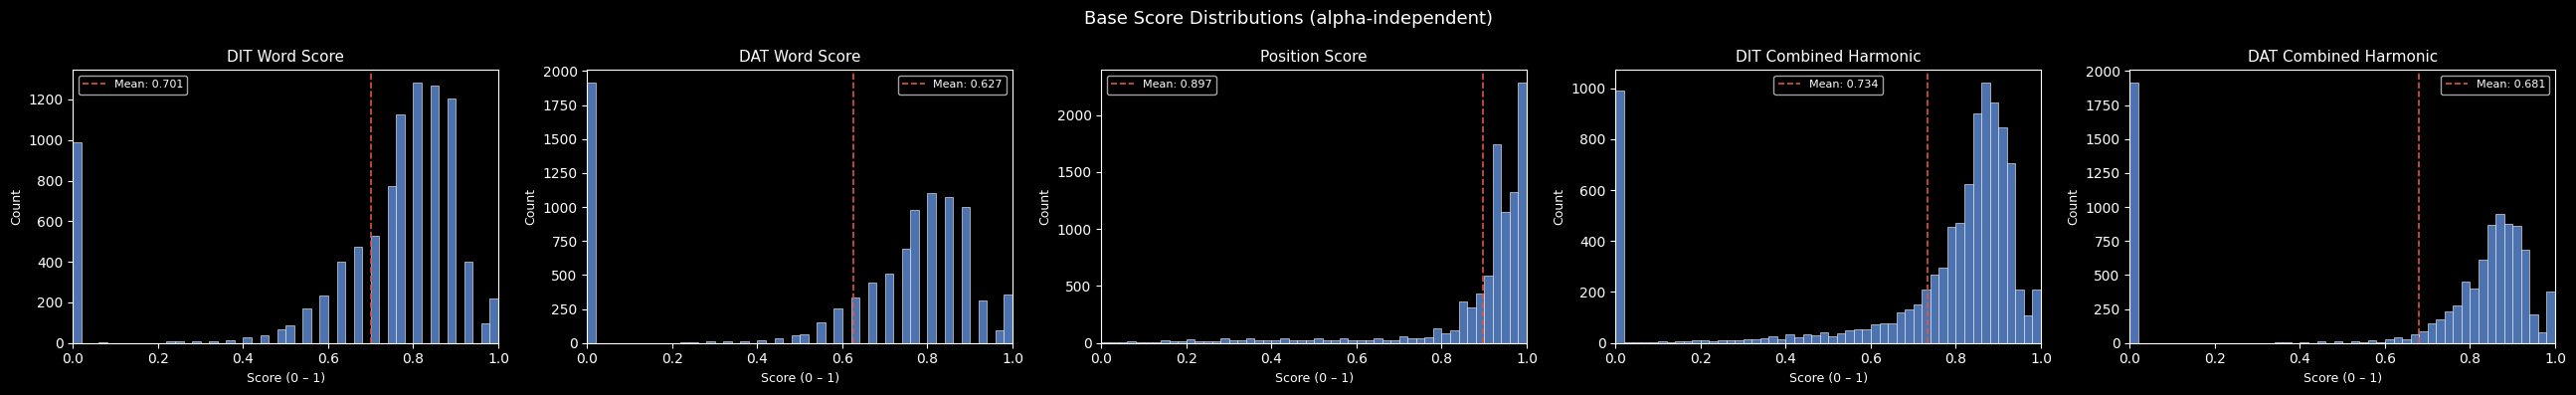

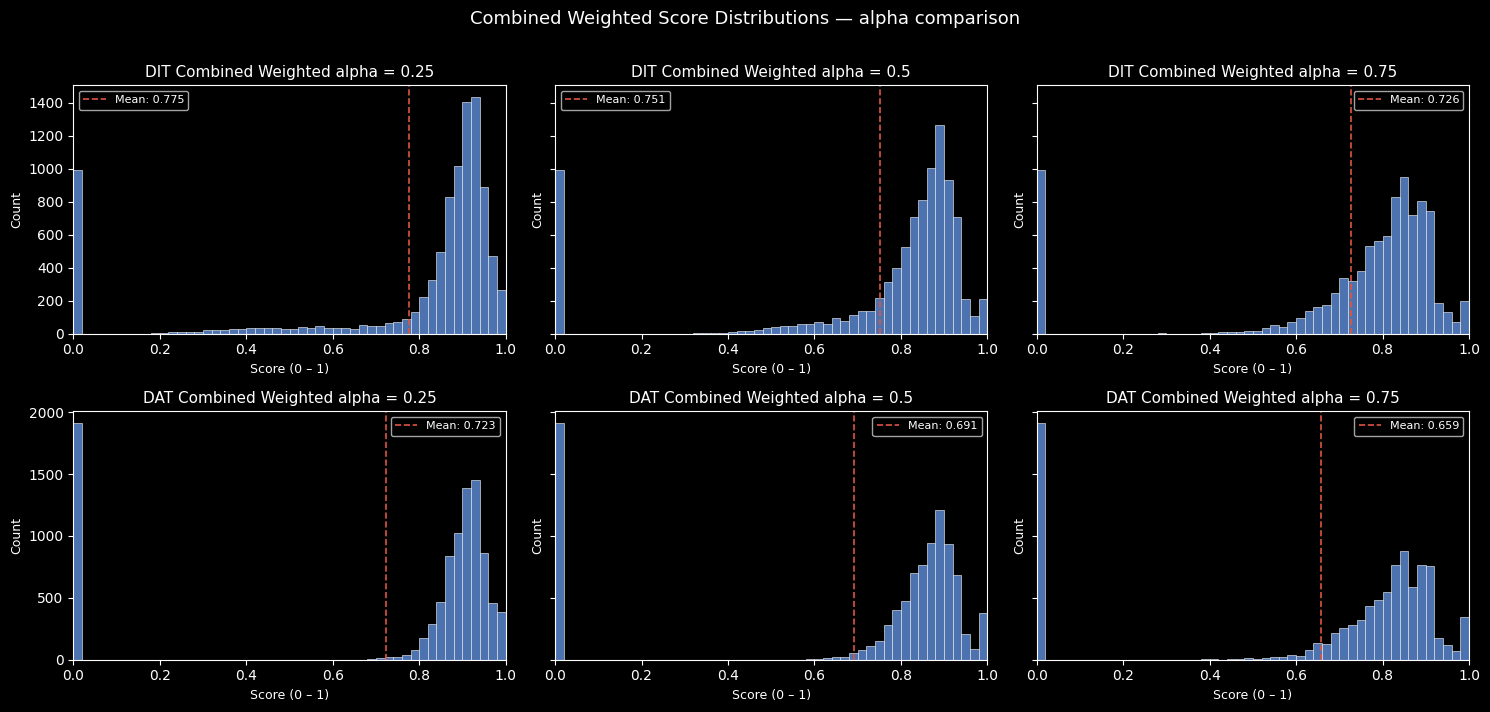

In [10]:
# 1) Base scores (alpha-independent) — shown once
plot_base_scores(next(iter(results.values())))

# 2) Combined scores for all alphas side-by-side
plot_combined_scores(results, ALPHAS)

### Best matchings — Harmonic (alpha-independent)

In [11]:
best_matchings_df(results[0.5], "DIT", score_type="harmonic").head(100)

,clip_id,src_word_index,src_word,dit_word,dit_score_harmonic
0,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,0,an,ist,0.934
1,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,1,den,her,0.947
2,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,2,mag,cos,0.941
3,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,3,ich,ist,0.947
4,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,4,mich,ist,0.920
...,...,...,...,...,...
95,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,1,einem,im,0.934
96,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,2,ersten,ersten,0.992
97,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,3,schritt,schritt,0.992
98,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,4,wurde,wurde,0.992


In [12]:
best_matchings_df(results[0.5], "DAT", score_type="harmonic").head(100)

,clip_id,src_word_index,src_word,dat_word,dat_score_harmonic
0,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,0,an,barb,0.934
1,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,1,den,barb,0.920
2,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,2,mag,barb,0.934
3,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,3,ich,barb,0.907
4,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,4,mich,barb,0.900
...,...,...,...,...,...
95,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,1,einem,einer,0.981
96,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,2,ersten,ersten,1.000
97,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,3,schritt,schritt,1.000
98,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,4,wurde,wurde,1.000


### Best matchings — Weighted α = 0.25

In [13]:
best_matchings_df(results[0.25], "DIT", score_type="weighted").head(100)

,clip_id,src_word_index,src_word,dit_word,dit_score_weighted
0,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,0,an,ist,0.960
1,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,1,den,ist,0.972
2,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,2,mag,cos,0.972
3,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,3,ich,her,0.972
4,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,4,mich,her,0.951
...,...,...,...,...,...
95,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,1,einem,ersten,0.963
96,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,2,ersten,ersten,0.988
97,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,3,schritt,schritt,0.988
98,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,4,wurde,wurde,0.988


In [14]:
best_matchings_df(results[0.25], "DAT", score_type="weighted").head(100)

,clip_id,src_word_index,src_word,dat_word,dat_score_weighted
0,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,0,an,barb,0.960
1,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,1,den,barb,0.963
2,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,2,mag,barb,0.960
3,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,3,ich,disapp,0.942
4,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,4,mich,disapp,0.930
...,...,...,...,...,...
95,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,1,einem,einer,0.991
96,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,2,ersten,ersten,1.000
97,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,3,schritt,schritt,1.000
98,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,4,wurde,wurde,1.000


### Best matchings — Weighted α = 0.5

In [15]:
best_matchings_df(results[0.5], "DIT", score_type="weighted").head(100)

,clip_id,src_word_index,src_word,dit_word,dit_score_weighted
0,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,0,an,ist,0.936
1,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,1,den,her,0.948
2,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,2,mag,cos,0.945
3,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,3,ich,ist,0.948
4,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,4,mich,ist,0.921
...,...,...,...,...,...
95,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,1,einem,im,0.936
96,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,2,ersten,ersten,0.992
97,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,3,schritt,schritt,0.992
98,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,4,wurde,wurde,0.992


In [16]:
best_matchings_df(results[0.5], "DAT", score_type="weighted").head(100)

,clip_id,src_word_index,src_word,dat_word,dat_score_weighted
0,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,0,an,barb,0.936
1,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,1,den,barb,0.926
2,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,2,mag,barb,0.936
3,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,3,ich,barb,0.910
4,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,4,mich,barb,0.902
...,...,...,...,...,...
95,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,1,einem,einer,0.982
96,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,2,ersten,ersten,1.000
97,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,3,schritt,schritt,1.000
98,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,4,wurde,wurde,1.000


### Best matchings — Weighted α = 0.75

In [17]:
best_matchings_df(results[0.75], "DIT", score_type="weighted").head(100)

,clip_id,src_word_index,src_word,dit_word,dit_score_weighted
0,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,0,an,ist,0.913
1,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,1,den,her,0.937
2,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,2,mag,cos,0.917
3,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,3,ich,ist,0.937
4,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,4,mich,ist,0.905
...,...,...,...,...,...
95,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,1,einem,im,0.913
96,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,2,ersten,ersten,0.996
97,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,3,schritt,schritt,0.996
98,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,4,wurde,wurde,0.996


In [18]:
best_matchings_df(results[0.75], "DAT", score_type="weighted").head(100)


,clip_id,src_word_index,src_word,dat_word,dat_score_weighted
0,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,0,an,barb,0.913
1,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,1,den,barb,0.889
2,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,2,mag,barb,0.913
3,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,3,ich,barb,0.881
4,clips\00fafc97-bf8b-4f35-ae97-b22e83e150f2\469...,4,mich,barb,0.877
...,...,...,...,...,...
95,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,1,einem,einer,0.972
96,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,2,ersten,ersten,1.000
97,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,3,schritt,schritt,1.000
98,clips\0f19ca1d-11fe-4822-83e9-4d0f7bcce0cd\d4b...,4,wurde,wurde,1.000
